# Fourrier Analysis 

Let's start this story with a wave, a simple cosine wave will do...


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import math

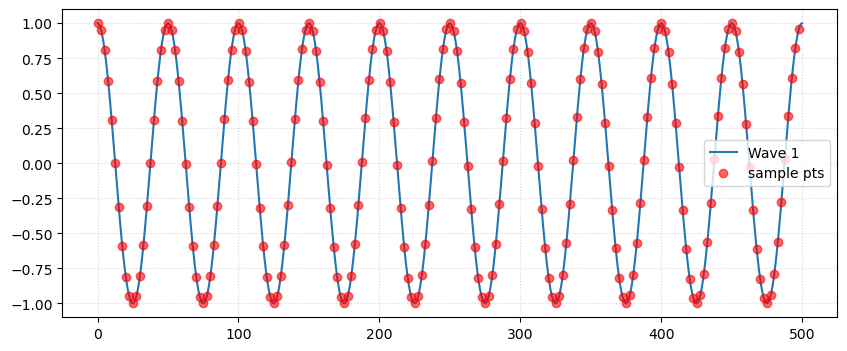

In [21]:
def add_wave(ax, x, freq=0.02, amplitude=1, phi=0, samples_per_wavelength=20, label='Sine Wave'):
    # y = A * sin(2pi * f * x + phi)
    y = amplitude * np.cos(2 * np.pi * freq * x + phi)
    
    # Calculate skip step (pss) based on user's samples_per_wavelength
    # (Points in one wavelength) / (Desired samples in one wavelength)
    wavelength = 1 / freq
    points_per_unit = len(x) / (x[-1] - x[0])
    pss = max(1, int((points_per_unit * wavelength) / samples_per_wavelength))
    
    line, = ax.plot(x, y, label=label)
    ax.plot(x[::pss], y[::pss], 'ro', markersize=6, alpha=0.6,label="sample pts")
    return ax

# Define global X-axis
x_fixed = np.linspace(0, 500, 2000)

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 4))

# Plot the first wave
freq=0.02
amplitude=1
add_wave(ax, x_fixed, freq=freq, amplitude=amplitude, label='Wave 1')

ax.legend()
ax.grid(True, linestyle=':', alpha=0.5)

### Discussion
<details>
<summary>1) If we have 10 waves and 20 samples per wave, how many red points are required to prepresent the series?</summary>

Trivial really, if we have 20 red dots per wave, then 200 points are required to represent this curve

</details>

<details>
<summary>
2) If we instead represent the data as a cosine how many numbers are required to represent the data?    
</summary>
We can represent this snippet exactly as part of an infinite cosine wave. And to describe that wave we just need to know the 
    
    * wavelength
    * magnitude 

</details>

## Magnitude and Frequency

So we can represent the cosine wave exactly in a continuous form: $$y=A cos(2 \pi f t) $$ where $f$ is the frequency of the cosine in cycles per unit time, $t$ is the time and $A$ is the amplitude of the wave.  This means that instead of 200 datapoints, we could represent this wave with two real numbers, $A$ and $f$. 

## Phase 

But we are forgetting a detail, because we also have another degree of freedom.  We could shift the curve to the right or left, by a discrete amount of time $t_0$

$y=A cos(2 \pi f (t + t_0)) $

By convention we can write this as 

$y=A cos(2 \pi f (t + t_0)) = A cos (2 \pi t + \phi)$

where $$\phi=2\pi f t_0$$ is known as the **phase** in radians.  We can show this by shifting the curve by a 6th of a cycle ($\phi=2\pi/6$)


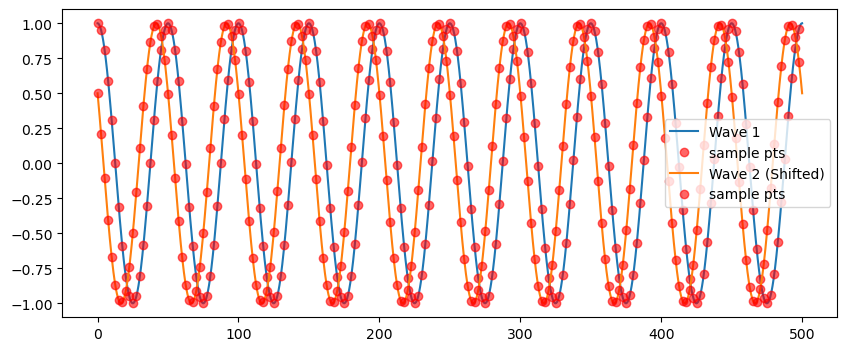

In [22]:

plt.close()
fig,ax = plt.subplots(figsize=(10, 4))

add_wave(ax, x_fixed, label='Wave 1')
add_wave(ax, x_fixed, phi=np.pi/3, label='Wave 2 (Shifted)')

# Update the legend to show the new entry
ax.legend()


## The neatness of the Complex Space :-)

So... if someone were to tell you the frequency $f$, phase $\phi$ and magnitude $A$, of the cosine wave $y=M cos(ft+\phi)$$ you could perfectly reconstruct the wave.  Alternatively they could provide you with the set of data of x-y points to reconstruct a discrete approximation of the wave. 

But in general we can instead represent this information as a complex number, using the follow trigonometric relation $cos(f+g)=cos(f)cos(g)-sin(f)sin(g)$. This equivalence us to write our cosine as a sum of a cosine and sine:

$$y(t) = A\cos(2\pi f t + \phi) = \underbrace{[A\cos(\phi)]}_{\text{Real Weight}} \cos(2\pi ft) - \underbrace{[A\sin(\phi)]}_{\text{Imaginary Weight}} \sin(2\pi ft)$$

This is very elegant, as now for a given wave frequency $f$, we can define the wave uniquely as a complex number $z = a + b j$.

> **Note:** We use $j$ instead of the more common $i$ for complex numbers as it is standard in engineering contexts where the FFT analysis was originally developed and also because it is the mandatory notation used in python and thus avoids notation confusion!

Here, the real part $a$ is the cosine weight:

$$a=Acos(\phi)$$

and likewise the imaginary part is the sine weight

$$b=Asin(\phi)$$

we can calculate the amplitude of the wave:

$$A=\sqrt{a^2 + b^2}$$

And finally we can calculate the phase using the *4-quadrant inverse tangent* function atan2, as follows

$$-\operatorname{atan2}(b, a)$$

> **Note:** We use `atan2(imag, real)` because it correctly identifies which of the 4 quadrants the phase is in by looking at the signs of $a$ and $b$ individually.

### From Trigonometry to the Complex Plane: Euler's Relation

To understand why the FFT gives us complex numbers ($a + b j$), we use **Euler's Relation**. This formula connects exponential functions to trigonometry:

$$e^{j\theta} = \cos(\theta) + j\sin(\theta)$$

When we analyze a signal $x(t) = A \cos(2\pi f t + \phi)$, the FFT looks for a complex coefficient ($z$) that represents this wave at frequency $f$. We can write our wave in "Complex Phasor" form as:

$$A e^{j\phi} = \underbrace{A \cos(\phi)}_{\text{Real Part (a)}} + j \underbrace{A \sin(\phi)}_{\text{Imaginary Part (b)}}$$

#### How to read the FFT Output:
If the FFT result for a specific frequency is the complex number $z = a + bi$:

1. **The Real Part ($a$):** Tells us the strength of the **Cosine** component ($A \cos \phi$).
2. **The Imaginary Part ($b$):** Tells us the strength of the **Sine** component ($-A \sin \phi$).
3. **The Magnitude ($|z|$):** Use the Pythagorean theorem to find the total Amplitude ($A$):
   $$A = \sqrt{a^2 + b^2}$$
4. **The Phase ($\phi$):** Use the 4-quadrant inverse tangent to find the starting shift:
   $$\phi = -\operatorname{atan2}(b, a)$$


Okay, this was for a single sinewave.  But what about other more generalized series and forms?  Well it turns out that any function in time (or space) can be represented by a sum of cosines!  (When Fourier first introduced this idea it was apparently rejected by many of the leading mathematicians of the idea for quite some time!)

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# 1. Parameters
n_modes=10 # we will build up the signal with this many modes from most important first
n_waves=6  #  Our fake signal has n_waves added together plus white noise
noise_mag=0.5


n_points = 1000
x = np.linspace(0, 1, n_points)
np.random.seed(42) # For consistent results, seed it to the answer of life and the universe!

# 2. Create 6 random underlying frequencies
# bounds are hardwired for each category at the moment...
freqs = np.random.uniform(5, 50, n_waves)
amps = np.random.uniform(0.5, 2.0, n_waves)
phases = np.random.uniform(0, 2*np.pi, n_waves)

# Build the "Clean" signal
clean_signal = np.zeros(n_points)
for f, a, p in zip(freqs, amps, phases):
    clean_signal += a * np.cos(2 * np.pi * f * x + p)

# Add significant white noise
noise = np.random.normal(0, noise_mag, n_points)
noisy_signal = clean_signal + noise

# 3. Analyze the signal using FFT to find the modes
fft_values = np.fft.rfft(noisy_signal)
frequencies = np.fft.rfftfreq(n_points, d=x[1]-x[0])

# Get indices of the top 10 strongest magnitudes (modes)
magnitudes = np.abs(fft_values) # SQRT(a**2+ b**2)

# We skip the 0th index (DC offset) and pick the top 10≈
indices = np.argsort(magnitudes[1:])[::-1][:n_modes] + 1 

# Pre-calculate variance of the noisy signal for the EV formula
total_variance = np.var(noisy_signal)

# 4. Set up the Animation Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, noisy_signal, color='gray', alpha=0.7, label='Noisy Data')
line, = ax.plot([], [], color='blue', lw=2, label='Fourier Reconstruction')
text = ax.text(0.02, 0.95, '', transform=ax.transAxes, fontweight='bold')

ax.set_xlim(0, 1)
ax.set_ylim(noisy_signal.min()-1, noisy_signal.max()+1)
ax.legend(loc='upper right')

def init():
    line.set_data([], [])
    return line,

def update(frame):
    # Sum up the first 'frame + 1' modes
    current_modes = indices[:frame]
    
    # Create a blank FFT array and only fill in our selected modes
    filtered_fft = np.zeros_like(fft_values)
    for idx in current_modes:
        filtered_fft[idx] = fft_values[idx]
    
    # Inverse FFT to get back the reconstructed time-domain signal
    reconstructed = np.fft.irfft(filtered_fft, n=n_points)

    # Calculate Explained Variance
    if frame == 0:
        ev = 0.0
    else:
        # Residual variance is the variance of the difference
        residual_variance = np.var(noisy_signal - reconstructed)
        ev = (1 - (residual_variance / total_variance)) * 100

    line.set_data(x, reconstructed)
    text.set_text(f"Modes: {frame:2d} | Explained Var: {ev:5.1f}%")

    return line, text

# Create Animation (frames 0 to 9 for 10 modes)
ani = FuncAnimation(fig, update, frames=range(n_modes+1), init_func=init, blit=True, interval=800)

# Display in Notebook
plt.close() # Prevents double plot
HTML(ani.to_jshtml())



## And Sharp Gradients?

So you might be asking yourself: *"That was easy because the data was made up of smooth waves, but what about data with sharp, vertical transitions?"* Interestingly, Fourier theory tells us that functions don't even need to be smooth (infinitely differentiable) to be represented by sinusoids. For example, we can reconstruct an **ideal square wave** with an amplitude of 1 by summing an infinite series of **cosines**:

$$f(t) = \frac{4}{\pi} \sum_{k=1}^{n} \frac{(-1)^{k-1}}{2k - 1} \cos(2\pi(2k - 1)ft)$$

Where:
* **$f$** is the frequency in **Hertz** (cycles per second).
* **$2\pi$** converts our frequency into angular velocity.
* The **$2k-1$** term ensures we only use **odd harmonics** (1st, 3rd, 5th, etc.).
* The **$(-1)^{k-1}$** term alternates the sign of each harmonic to "flatten" the top of the wave.

Let's try it out with a square wave of **one Hertz**!


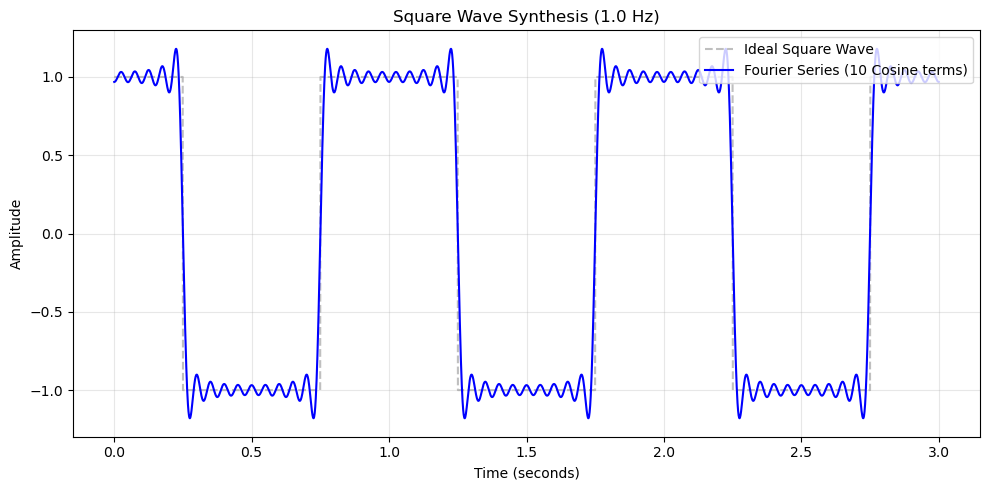

In [38]:
import numpy as np
import matplotlib.pyplot as plt

def square_wave(t, freq):
    """Generates a square wave with a specific frequency in Hz."""
    # Using Cosine-based sign to align with the Fourier series below
    return np.sign(np.cos(2 * np.pi * freq * t))

def sum_of_cosines(t, freq, num_terms):
    """Approximates a square wave using the Cosine Fourier Series."""
    approximation = np.zeros_like(t, dtype=float)
    for k in range(1, num_terms + 1):
        n = 2 * k - 1  # Only odd harmonics
        # The (-1)^(k-1) flips the sign for every other term to flatten the top
        term = (4 / (np.pi * n)) * ((-1)**(k-1)) * np.cos(n * 2 * np.pi * freq * t)
        approximation += term
    return approximation

# --- Parameters ---
frequency_hz = 1.0        # 1 cycle per second
duration_seconds = 3.0    # Show 3 seconds of data
sample_rate = 1000        # Points per second

time = np.linspace(0, duration_seconds, int(sample_rate * duration_seconds))
square_signal = square_wave(time, frequency_hz)

# --- Plotting ---
num_terms = 10
approximation = sum_of_cosines(time, frequency_hz, num_terms)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(time, square_signal, label='Ideal Square Wave', color='gray', linestyle='--', alpha=0.5)
ax.plot(time, approximation, label=f'Fourier Series ({num_terms} Cosine terms)', color='blue')

ax.set_title(f'Square Wave Synthesis ({frequency_hz} Hz)')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Amplitude')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Exercise

With start with one term by default, but try increasing this and rerunning the following code...


> <div style="padding: 15px; border: 1px solid #1565C0; border-left: 6px solid #1565C0; background-color: #E3F2FD; color: #0D47A1; border-radius: 4px;">
> <strong>⚠️ The Gibbs Phenomenon</strong><br>
> Notice the "ringing" or overshooting at the sharp corners of the square wave? This is known as the <strong>Gibbs Phenomenon</strong>. Because we are using continuous, smooth waves (cosines) to approximate a discontinuous jump, the sum will always overshoot the target by about 9%, no matter how many terms you add! It only disappears when you have an <em>infinite</em> number of terms.
> </div>


# Fourier Series

Let's imagine then any function at all that is periodic (later we will see this holds for non periodic signals).

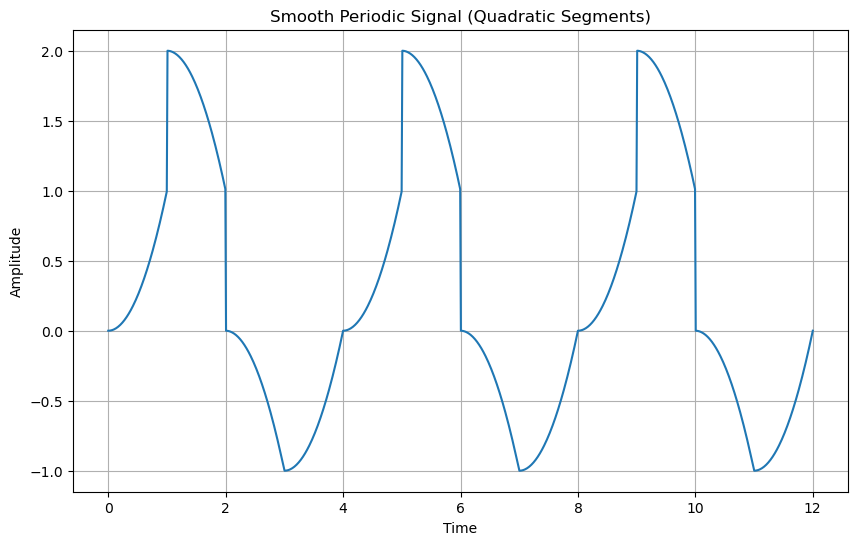

In [45]:
import numpy as np
import matplotlib.pyplot as plt

def generate_smooth_periodic_signal_alt(t):
    """Generates a smooth periodic signal using different functions (no sin/cos, no noise)."""
    signal = np.zeros_like(t, dtype=float)
    for i, time_val in enumerate(t):
        phase = time_val % 4
        if 0 <= phase < 1:
            signal[i] = phase**2  # Quadratic rise
        elif 1 <= phase < 2:
            signal[i] = 2 - (phase - 1)**2  # Inverted quadratic peak
        elif 2 <= phase < 3:
            signal[i] = -(phase - 2)**2 # quadratic fall
        else:
            signal[i] = (phase-3)**2 - 1 # quadratic dip
    return signal

# Parameters
period = 4  # Period of the signal (for time range)
time = np.linspace(0, 12, 1000)  # Time range for plotting (3 periods)

# Generate the signal
smooth_periodic_signal = generate_smooth_periodic_signal_alt(time)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(time, smooth_periodic_signal)
plt.title("Smooth Periodic Signal (Quadratic Segments)")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

Fourier determined that such a function can be represented as a series of sines and cosines of different frequencies, called a Fourier Series. 

There are two common forms of the Fourier Series, "Trigonometric" and "Exponential." These are discussed below, followed by a demonstration that the two forms are equivalent: 

Trigonometric Form (Sum of Sines and Cosines)
$$ x(t) = a_0 + \sum_{n=1}^{\infty} \left[ a_n \cos(n \omega_0 t) + b_n \sin(n \omega_0 t) \right] $$

Complex Exponential Form (Sum of Complex Numbers)
$$x(t) = \sum_{n=-\infty}^{\infty} c_n e^{j n \omega_0 t} $$

Where $\omega_0$ is the frequency of the periodic signal.  

So essentially Fourier suggested an incredible thing, that essentially we can represent any signal alternatively in a "frequency" (or wavelength) space, as a series of curves of a given wave length, we just need to find out how to calculate the amplitude (and phase) of each sinewave, essentially the coefficient $c_i$. This is useful because we may find that particular wavelengths/frequencies have much higher $c_i$ values, implying that this frequency is particularly pronounced in the signal, something that is not always immediately obvious when looking at the original signal in space or time $x(t)$.

While we will show an application in meteorology, Fourier transforms have found use in almost every field on the planet!  Here are just a couple of examples from betterexplained.com:

- **Earthquakes** If earthquake vibrations can be separated into "ingredients" (vibrations of different speeds & amplitudes), buildings can be designed to avoid interacting with the strongest ones.

- **Filters** If sound waves can be separated into ingredients (bass and treble frequencies), we can boost the parts we care about, and hide the ones we don't. The crackle of random noise can be removed. Maybe similar "sound recipes" can be compared (music recognition services compare recipes, not the raw audio clips).

- **Compression** If computer data can be represented with oscillating patterns, perhaps the least-important ones can be ignored. This "lossy compression" can drastically shrink file sizes (and why JPEG and MP3 files are much smaller than raw .bmp or .wav files).  Most compression methods in use these days use a related wavelet based approach.



## Discrete Fourier transform (DFT)

The DFT of a series of $n$ data points (where $n$ is typically assumed to be even for simplicity, though DFTs can be calculated for odd $n$) produces $n$ complex numbers. These complex numbers represent the frequency components of the signal.  Each complex number corresponds to a specific frequency. However, these frequency components aren't just sine waves. They represent both sine and cosine waves (or, equivalently, sine waves with phase shifts).

Let $x[n]$ represent a discrete-time signal, where $n$ is an integer index representing the time sample, and $n = 0, 1, ..., N-1$, with $N$ being the total number of samples. The Discrete Fourier Transform (DFT) of $x[n]$, denoted as $X[k]$, is defined as:

$$X[k] = \sum_{n=0}^{N-1} x[n] e^{-j 2\pi k n/N}$$

where $k = 0, 1, ..., N-1$ represents the frequency index, and $j$ is the imaginary unit ($j^2 = -1$). The $e^{-j 2\pi kn/N}$ term represents a complex sinusoid at frequency $k/N$.  Essentially what we are doing is a **convolution** of the signal with the complex wave form, for each wavenumber. 

The DFT decomposes the signal $x[n]$ into a sum of complex sinusoids, each with a specific frequency and amplitude. The output $X[k]$ is a complex-valued sequence, where the magnitude $|X[k]|$ represents the amplitude of the frequency component $k/N$, and the phase $\arg(X[k])$ represents the phase shift of that component.

So to summarize, the amplitude spectrum of the signal is obtained by computing the magnitude $|X[k]|$ of the DFT coefficients and the power spectrum is given by $|X[k]|^2$.

The frequency corresponding to the $k$-th DFT coefficient is:

$$f_k = k \Delta f = \frac{k f_s}{N}$$

The inverse DFT (IDFT) reconstructs the original signal $x[n]$ from its DFT coefficients $X[k]$:

$$x[n] = \frac{1}{N} \sum_{k=0}^{N-1} X[k] e^{j 2\pi kn/N}$$

For a **real-valued input signal** $x[n]$, the DFT output $X[k]$ exhibits conjugate symmetry, i.e., $X[k] = X^*[N-k]$, where $*$ denotes complex conjugation. This means that the negative frequency components ($k > N/2$) are redundant, and we typically focus on the positive frequency components ($k \le N/2$).

### The Fast Fourier Transform (FFT) 

The FFT is an efficient algorithm to compute the DFT and IDFT. It leverages the symmetry and periodicity properties of the complex exponential term to reduce the computational complexity from $O(N^2)$ for the direct DFT calculation to $O(N \log N)$.



The frequency resolution $\Delta f$ of the DFT is given by:

$$\Delta f = \frac{f_s}{N}$$

where $f_s$ is the sampling frequency (the number of samples per unit time). The maximum frequency that can be represented without **aliasing** is the Nyquist frequency, which is half the sampling frequency:

$$f_{Nyquist} = \frac{f_s}{2}$$

We can illustrate this by returning to the first plot 

In [46]:
sinewave_plt(s=1.3)

NameError: name 'sinewave_plt' is not defined

Essentially we need sampling at a rate of more than two points per wave.  

### Aliasing 

Aliasing occurs if we reduce the sample rate further:

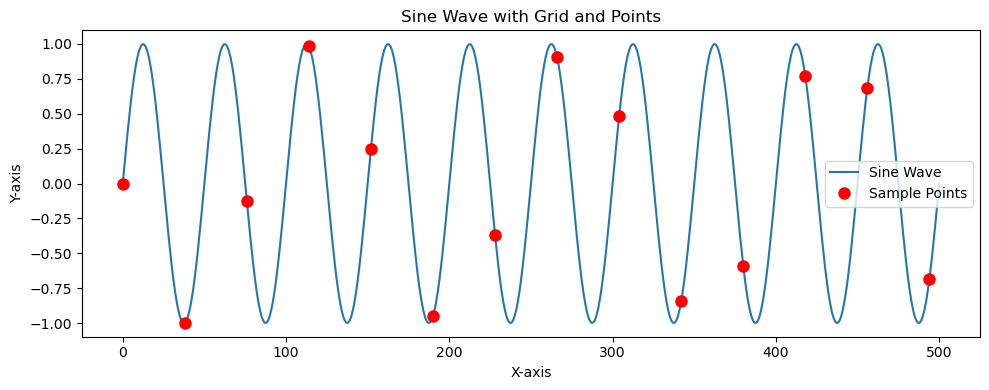

In [6]:
sinewave_plt(ss=1.3)

Here we see that at a slower rate, the red dots trace a wave that has a longer wavelength than the blue line. This is known as "aliasing" where the power at one frequency is artifically projected onto a lower frequency due to undersampling.

Okay, let's try an example. Here we will analysis an hourly temperature series for Trieste that spans about ten years.

In [7]:
#%pip install cftime

In [8]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import urllib.request
import cftime
import datetime

In [9]:
def analyze_time_series_fft(time_series, times, units):
    """
    Analyzes a time series using FFT and returns the frequencies, periods, and amplitudes.

    Args:
        time_series (np.ndarray or xr.DataArray): The time series data.
        time_coords (np.ndarray or xr.DataArray): Corresponding time coordinates.

    Returns:
        tuple: (frequencies, periods, amplitudes)
    """
   

    # Calculate the sampling period in days
    time_diffs = np.diff(times)
    if len(np.unique(time_diffs)) != 1:
        raise ValueError("Time coordinates must be evenly spaced.")

    # Determine time units and convert to days
    if isinstance(times[0], datetime.datetime):
        time_diff_days = np.mean([td.total_seconds() / (60 * 60 * 24) for td in time_diffs])
    else:
        try:
            # units = time_coords.units
            print (units, " units")
            if 'second' in units.lower():
                print ("sec detected")
                time_diff_days = np.mean(time_diffs) / (60 * 60 * 24)
            elif 'minute' in units.lower():
                time_diff_days = np.mean(time_diffs) / (60 * 24)
            elif 'hour' in units.lower():
                print ("hours detected")
                time_diff_days = np.mean(time_diffs) / 24
            elif 'day' in units.lower():
                time_diff_days = np.mean(time_diffs)
            else:
                time_diff_days = np.mean(time_diffs) / (60 * 60 * 24)  # assume seconds if units not recognized.
        except AttributeError:
            time_diff_days = np.mean(time_diffs) / (60 * 60 * 24)  # assume seconds if no units attribute.

    # Compute the FFT
    fft_result = np.fft.fft(time_series)

    # Calculate frequencies (in cycles per day)
    frequencies = np.fft.fftfreq(len(time_series), time_diff_days)

    # Calculate periods (in days) - handle zero frequency carefully
    periods = np.zeros_like(frequencies)

    # we only take the positive frequencies as the 
    # input is a real function, not complex.
    positive_freq_indices = frequencies > 0
    periods[positive_freq_indices] = 1 / frequencies[positive_freq_indices]
    periods[frequencies == 0] = np.inf  # Period is infinite for zero frequency

    # Calculate amplitudes
    amplitudes = np.abs(fft_result)

    return frequencies, periods, amplitudes






We will also introduce a separate plotting routine in order to keep things clean


In [91]:

def plot_fft_spectrum(frequencies, periods, amplitudes):
    """
    Plots the frequency spectrum.

    Args:
        frequencies (np.ndarray): Frequencies (cycles/day).
        periods (np.ndarray): Periods (days).
        amplitudes (np.ndarray): Amplitudes.
    """

    positive_freq_indices = frequencies > 0

    fig, ax = plt.subplots(figsize=(10, 6))  # Create figure and axes

    ax.plot(periods[positive_freq_indices], amplitudes[positive_freq_indices])
    ax.set_xlabel("Period (days)")
    ax.set_ylabel("Amplitude (log scale)")
    ax.set_title("Frequency Spectrum")
    ax.grid(True)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlim(365 * 10,0.1)

    return fig,ax

decode
seconds since 1970-01-01  units
sec detected


Text(1, 1, 'day')

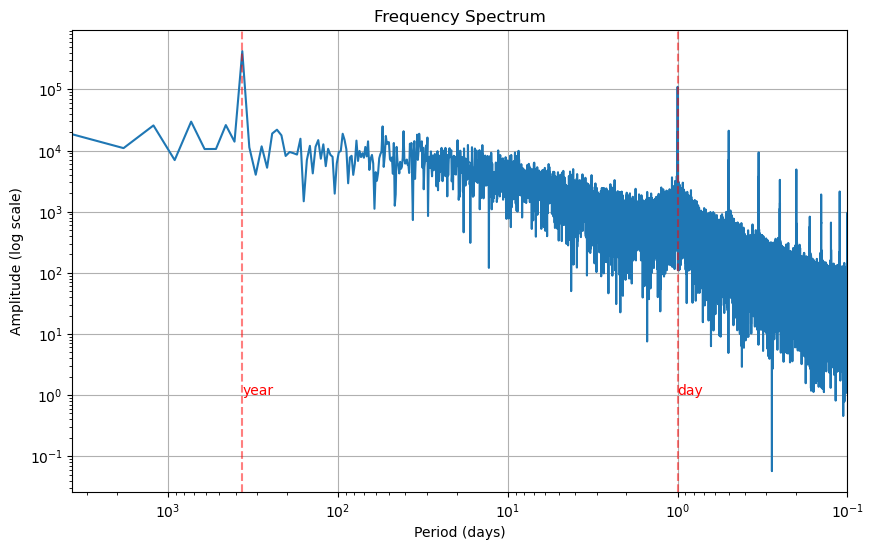

In [94]:

# Download example data
# url = "https://downloads.psl.noaa.gov/Datasets/era5/hourly/air.2m.2023.nc"
# filename = "air.2m.2023.nc"
# urllib.request.urlretrieve(url, filename)

datadir="/Users/tompkins/DATA/era5/hourly/"
filename=datadir+"t2m_t.nc"

# Open the NetCDF file
decode_times=False
ds = xr.open_dataset(filename, decode_times=decode_times)
if not decode_times:
    print ("decode")
    time_units = ds["valid_time"].units
    time_values = ds["valid_time"].values

    # Extract the base date from the time units
    base_date_str = time_units.split('since ')[1]

    # Convert seconds to datetime objects
    times = cftime.num2date(time_values, units = time_units, calendar = 'standard')

    # Replace the time coordinate
    # ds['time'] = datetimes

# Select a specific location and time range
lat = 45.6
lon = 13.7
t2m = ds["t2m"].sel(latitude=lat, longitude=lon,method='nearest')
# time = ds['time']

# Perform FFT analysis
frequencies, periods, amplitudes = analyze_time_series_fft(t2m, time_values, time_units)
fig,ax=plot_fft_spectrum(frequencies, periods, amplitudes)

ax.axvline(x=365, color='red', linestyle='--',alpha=0.5)
ax.text(365,1,"year",color='red')
ax.axvline(x=1, color='red', linestyle='--',alpha=0.5)
ax.text(1,1,"day",color='red')


### Discussion

- What do you notice about the general slope, what period general has more power?  This is an example of a **red** spectrum
- Do you notice any spectral peaks that stand out?  Are they there by chance do you think, or do they have physical significance?  Did you expect these peaks?
- What about the sub-daily peaks?

In [42]:
import numpy as np
from scipy.signal import savgol_filter

def calculate_significant_peaks_smoothed(amplitudes, window_length=15, polyorder=3, threshold_factor=2.0):
    """
    Calculates significant peaks by comparing amplitudes to a smoothed spectrum.

    Args:
        amplitudes (np.ndarray): The FFT amplitudes.
        window_length (int): Length of the smoothing window (must be odd).
        polyorder (int): Order of the polynomial used in smoothing.
        threshold_factor (float): Factor to multiply the smoothed amplitudes for threshold.

    Returns:
        np.ndarray: Boolean array indicating significant peaks.
    """

    # Smooth the amplitudes using Savitzky-Golay filter
    smoothed_amplitudes = savgol_filter(amplitudes, window_length, polyorder)

    # Calculate the significance threshold
    significance_threshold = smoothed_amplitudes * threshold_factor

    # Determine significant peaks
    significant_peaks = amplitudes > significance_threshold

    return significant_peaks, significance_threshold

In [41]:
#sig_peaks=calculate_significant_peaks(amplitudes)
sig_peaks,thresh=calculate_significant_peaks_smoothed(amplitudes,window_length=20,threshold_factor=4)

NameError: name 'amplitudes' is not defined

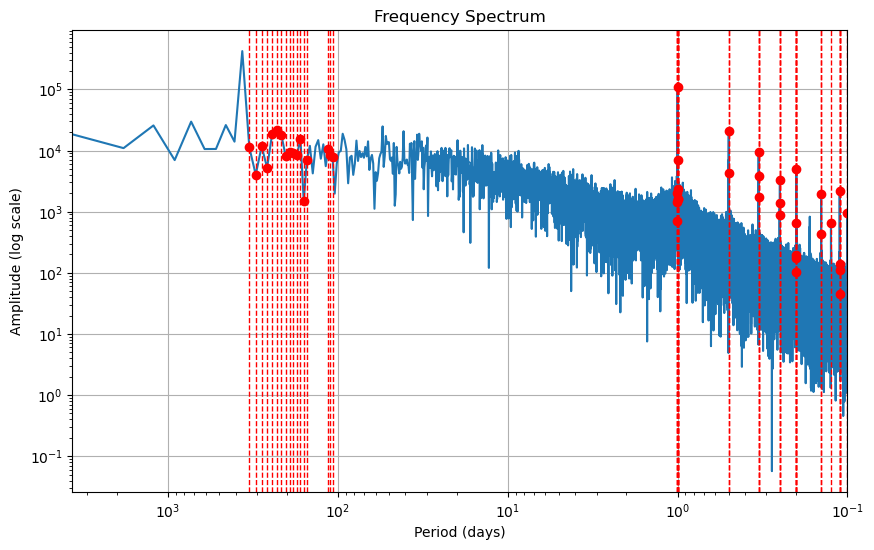

In [110]:
fig,ax=plot_fft_spectrum(frequencies, periods, amplitudes)

# Plot vertical lines at significant peaks
positive_freq_indices = frequencies > 0
peak_periods = periods[positive_freq_indices][sig_peaks[positive_freq_indices]]
peak_amplitudes = amplitudes[positive_freq_indices][sig_peaks[positive_freq_indices]]

ax.line(
for period, amplitude in zip(peak_periods, peak_amplitudes):
    ax.axvline(x=period, color='red', linestyle='--', linewidth=1) # add vertical lines
    ax.plot(period, amplitude, 'ro') # add red dot on peak
